# 11 · Reactivity and preemption

## Learning objectives

- Switch priorities while work runs.
- Observe INVALID on interrupted work.
- Explain the risk of memory in safety guards.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

**Preemption** means withdrawing a lower-priority request because something more urgent
needs attention. A reactive selector revisits its first child every tick. A safety branch
usually contains a condition and a response. When that branch becomes active, a running
lower-priority action is invalidated and its terminate hook can cancel external work.
A software BT is not a replacement for independent hardware safety mechanisms.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

['initialise', 'update 1', 'terminate INVALID']


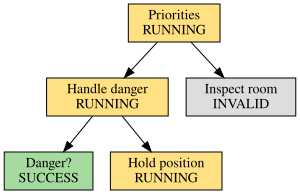

In [3]:
world = {"danger": False}
work = CountTicks("Inspect room", ticks=10)
root = pt.composites.Selector("Priorities", memory=False, children=[
    pt.composites.Sequence("Handle danger", memory=False, children=[
        Function("Danger?", lambda: Status.SUCCESS if world["danger"] else Status.FAILURE),
        pt.behaviours.Running("Hold position"),
    ]), work,
])
root.tick_once()
assert work.status is Status.RUNNING
world["danger"] = True
root.tick_once()
assert work.status is Status.INVALID
assert "terminate INVALID" in work.events
print(work.events)
display(diagram(root))

## Step-by-step implementation
At first, Danger? fails and the selector tries Inspect room. Later, the safety branch runs,
so the selector stops the old child. When danger clears, Inspect room is entered again and
initialise resets its local counter. Resuming physical work would require explicit persistent
progress; it is a separate choice from resuming a composite index.

['initialise', 'update 1', 'terminate INVALID', 'initialise', 'update 1']


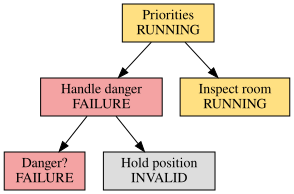

In [4]:
world["danger"] = False
root.tick_once()
assert work.count == 1
print(work.events)
display(diagram(root))

## Interactive demonstration

In [5]:
import ipywidgets as widgets

@widgets.interact(danger=False)
def change_priority(danger=False):
    world["danger"] = danger
    root.tick_once()
    display(diagram(root))
    print("Work progress:", work.count)

interactive(children=(Checkbox(value=False, description='danger'), Output()), _dom_classes=('widget-interact',…

## Key observations

Reactivity requires both revisiting a decision and correctly terminating displaced work. Remembered branches can hide changed conditions.

## Exercises

1. Change the outer selector to memory=True and repeat the interruption.
2. Preserve work progress across re-entry and explain when this is safe.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 11).

## Summary

Interruptible work supports priority changes. Recoverable failures need another policy: repairing the cause before trying again.